# Setup

**Imports**

In [19]:
import datetime as dt
from math import log
import IPython
import geopandas
import contextily as cx
from math import asin, cos, radians, sin, sqrt


from loadmydata.load_molene_meteo import load_molene_meteo_dataset
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import numpy as np
import ruptures as rpt
from scipy.fft import fft
from pygsp import graphs
from scipy.spatial.distance import pdist, squareform

rng = np.random.default_rng()
import matplotlib
matplotlib.rcParams = matplotlib.rcParamsDefault.copy()

import scipy.signal as signal
import librosa
import random
from collections import defaultdict

# Question 1

The following cell loads the training data set `X_train` and `y_train`.
`X_train` is a list of 100 signals; `y_train` is a list of 100 symbol sequences. 

The signals have a varying number of symbols with a varying duration. 
There is a brief silence between each symbol.
The sampling frequency is $22.05 $ kHz.

In [20]:
FS = 22050  # sampling frequency (Hz)

X_train = np.load("X_train.npy", allow_pickle=True).tolist()
X_test = np.load("X_test.npy", allow_pickle=True).tolist()
y_train = np.load("y_train.npy", allow_pickle=True).tolist()

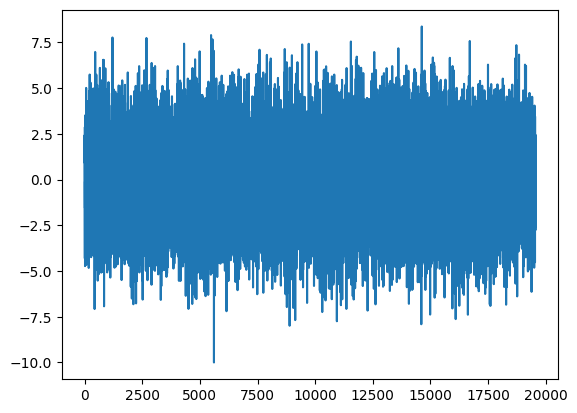

In [21]:
plt.plot(X_train[0])
plt.show()

In [22]:
signal_, symbols = X_train[2], y_train[2]
print(" ".join(symbols))
IPython.display.Audio(signal_, rate=FS)

D 6 A 8 3 D 1 8 B 9


In [23]:
def filter_overlapping_symbols(symbols, overlap_thresh=0.2):
    """
    keep only the strongest symbol when multiple detections overlap in time.
    """
    if not symbols: 
        return []
    
    # We want to prioritize the loudest/clearest detections
    sorted_symbols = sorted(symbols, key=lambda x: x['energy'], reverse=True)
    
    keep = []
    
    for current in sorted_symbols:
        is_overlapping = False
        
        for picked in keep:
            # Check overlap between current and an already picked symbol
            # Using Intersection over Union logic
            start1, end1 = current['time_start'], current['time_end']
            start2, end2 = picked['time_start'], picked['time_end']
            
            inter_start = max(start1, start2)
            inter_end = min(end1, end2)
            intersection = max(0, inter_end - inter_start)
            
            if intersection > 0:
                ratio = intersection / (end1 - start1)
                if ratio > overlap_thresh:
                    is_overlapping = True
                    break
        
        if not is_overlapping:
            keep.append(current)
            
    keep.sort(key=lambda x: x['time_start'])
    return keep

In [24]:
def merge_close_segments(segments, freq_threshold=30, time_gap_threshold=0.1):
    """
    Here we merge segments that are likely the same tone split across bins or time.
    """
    if not segments:
        return []

    n = len(segments)
    parent = list(range(n))

    def find(i):
        if parent[i] != i:
            parent[i] = find(parent[i])
        return parent[i]

    def union(i, j):
        root_i = find(i)
        root_j = find(j)
        if root_i != root_j:
            parent[root_i] = root_j

    # Compare every pair
    for i in range(n):
        for j in range(i + 1, n):
            seg1 = segments[i]
            seg2 = segments[j]
            
            # Frequency Check: Are they close?
            freq_diff = abs(seg1['freq'] - seg2['freq'])
            
            if freq_diff < freq_threshold:
                # Time Check: Do they overlap or is the gap small?
                # start2 <= end1 + gap  AND  start1 <= end2 + gap
                s1, e1 = seg1['time']
                s2, e2 = seg2['time']
                
                if (s2 <= e1 + time_gap_threshold) and (s1 <= e2 + time_gap_threshold):
                    union(i, j)

    # Group by Parent
    groups = {}
    for i in range(n):
        root = find(i)
        if root not in groups:
            groups[root] = []
        groups[root].append(segments[i])

    # Create Merged Segments
    merged_results = []
    for root in groups:
        group = groups[root]
        
        # New Start = Min Start
        new_start = min(s['time'][0] for s in group)
        # New End = Max End
        new_end = max(s['time'][1] for s in group)
        # New Freq = we average
        new_freq = sum(s['freq'] for s in group) / len(group)
        # New Energy = Max energy of the group
        new_energy = max(s['energy'] for s in group)
        
        merged_results.append({
            'freq': new_freq,
            'time': (new_start, new_end),
            'energy': new_energy,
            'bin': int(group[0]['bin'])
        })

    return merged_results

[{'time_start': 0.18575963718820862, 'time_end': 0.3947392290249433, 'freq_low': 689.0625, 'freq_high': 1489.3798828125, 'energy': -3.4758274131820697}, {'time_start': 0.5514739229024943, 'time_end': 0.6791836734693878, 'freq_low': 861.328125, 'freq_high': 1335.05859375, 'energy': -4.843021324457123}, {'time_start': 0.7256235827664399, 'time_end': 0.9926530612244898, 'freq_low': 775.1953125, 'freq_high': 1478.61328125, 'energy': -4.150367516062158}, {'time_start': 1.18421768707483, 'time_end': 1.2770975056689342, 'freq_low': 850.5615234375, 'freq_high': 1345.8251953125, 'energy': -4.776154627755094}, {'time_start': 1.5209070294784581, 'time_end': 1.6602267573696146, 'freq_low': 936.6943359375, 'freq_high': 1335.05859375, 'energy': -3.3805306444481826}, {'time_start': 1.8053514739229024, 'time_end': 1.921451247165533, 'freq_low': 1335.05859375, 'freq_high': 1636.5234375, 'energy': -9.77634688111434}, {'time_start': 2.0317460317460316, 'time_end': 2.1942857142857144, 'freq_low': 846.9726

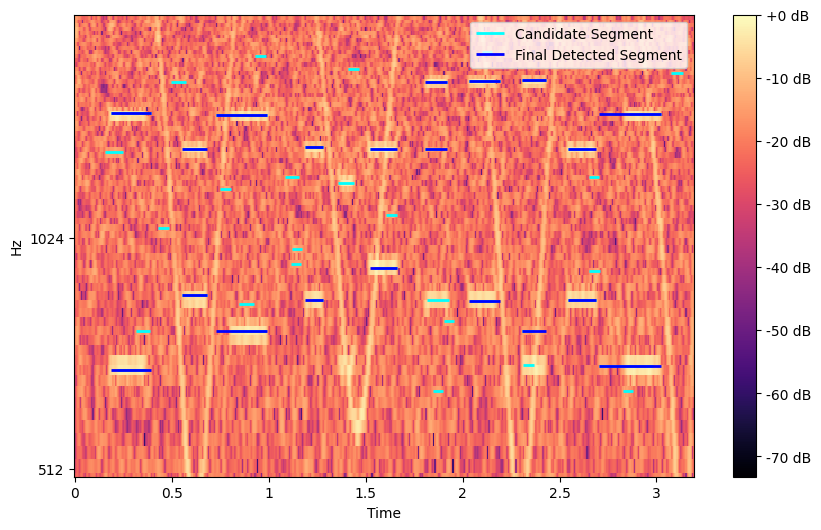

In [ ]:
def get_iou(seg1, seg2):
    """
    Calculates Intersection over Union for two time segments.
    seg = (start_time, end_time)

    """
    start1, end1 = seg1
    start2, end2 = seg2

    # Calculate Intersection
    inter_start = max(start1, start2)
    inter_end = min(end1, end2)
    intersection = max(0, inter_end - inter_start)

    # instersection is more important in our case since the detection are usually short
    # union = (end1 - start1) + (end2 - start2) - intersection
    
    # if union == 0:
    #     return 0
    return intersection #/ union

def get_segments_frequency_rpt(wav, fs, iou_threshold=0.05):
    n_fft = 1024
    hop_length = n_fft//8
    pen = 10  # Penalty for change point detection
    min_duration = 0.05
    max_duration = 1.0

    D = librosa.stft(wav, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    frequencies = librosa.fft_frequencies(sr=fs, n_fft=n_fft)
    
    # COLLECT ALL SEGMENTS
    all_segments = []
    
    global_threshold = np.mean(S_db) + 6  # Only look at bins 6dB above average
    
    max_bin = np.searchsorted(frequencies, 1800)
    min_bin = np.searchsorted(frequencies, 500)

    for bin_idx in range(min_bin, max_bin):
        freq_bin = S_db[bin_idx, :]
        
        # Optimization: Skip quiet bins to speed up processing
        if np.max(freq_bin) < global_threshold:
            continue

        # Get change points
        algo = rpt.Pelt(model="l2", jump=1).fit(freq_bin)
        try:
            # Increased penalty to avoid fragmenting stable tones
            change_points = algo.predict(pen=pen) 
        except:
            continue

        # Convert to segments
        for i in range(len(change_points) - 1):
            start_frame = change_points[i]
            end_frame = change_points[i+1]
            
            # Check if this segment is actually "Active" (High Energy)
            # Ruptures detects edges, but we need to know if it's Sound or Silence.
            seg_energy = np.mean(freq_bin[start_frame:end_frame])
            if seg_energy > global_threshold:
                
                # Convert to seconds
                start_t = start_frame * hop_length / fs
                end_t = end_frame * hop_length / fs
                duration = end_t - start_t
                
                if min_duration <= duration <= max_duration: # > 40ms
                    all_segments.append({
                        'freq': frequencies[bin_idx],
                        'time': (start_t, end_t),
                        'bin': bin_idx,
                        'energy': seg_energy
                    })

    # We first look for segemnts that are close in frequency and merge them
    all_segments = merge_close_segments(all_segments)
    # We look for pairs of segments that overlap significantly
    detected_symbols = []
    
    # Sort by start time to make matching easier
    all_segments.sort(key=lambda x: x['time'][0])
    
    used_indices = set()
    
    for i in range(len(all_segments)):
        if i in used_indices:
            continue
            
        seg1 = all_segments[i]
        
        # Find best match for this segment
        best_match = None
        best_iou = 0
        match_idx = -1
        
        for j in range(i + 1, len(all_segments)):
            if j in used_indices:
                continue
            
            seg2 = all_segments[j]
            
            # Optimization: If seg2 starts after seg1 ends, stop looking
            if seg2['time'][0] > seg1['time'][1]:
                break
                
            iou = get_iou(seg1['time'], seg2['time'])
            
            if iou > iou_threshold:
                if abs(seg1['freq'] - seg2['freq']) > 200:
                    if iou > best_iou:
                        best_iou = iou
                        best_match = seg2
                        match_idx = j

        if best_match:
            # We found a pair!
            freqs = sorted([seg1['freq'], best_match['freq']])
            avg_energ = (seg1['energy'] + best_match['energy']) / 2
            detected_symbols.append({
                'time_start': min(seg1['time'][0], best_match['time'][0]),
                'time_end': max(seg1['time'][1], best_match['time'][1]),
                'freq_low': freqs[0],
                'freq_high': freqs[1],
                'energy': avg_energ
            })
            
            # Mark these as used so we don't double count
            used_indices.add(i)
            used_indices.add(match_idx)
    final_symbols = filter_overlapping_symbols(detected_symbols)
    return final_symbols, all_segments

n_fft = 1024
hop_length = n_fft//8
idx = random.randint(0, len(X_train))
segments, all_segments = get_segments_frequency_rpt(X_train[idx], FS)
plt.figure(figsize=(10, 6))
D = librosa.stft(X_train[idx], n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, sr=FS, hop_length=hop_length, x_axis='time', y_axis='log')
added_cand_label = False
for seg in all_segments:
    plt.hlines(y=seg['freq'], xmin=seg['time'][0], xmax=seg['time'][1], colors='cyan', linewidth=2, label='Candidate Segment' if not added_cand_label else "")
    added_cand_label = True
print(segments)
added_final_label = False
for seg in segments:
    lbl = 'Final Detected Segment' if not added_final_label else ""
    plt.hlines(y=seg['freq_low'], xmin=seg['time_start'], xmax=seg['time_end'], colors='b', linewidth=2, label=lbl)
    plt.hlines(y=seg['freq_high'], xmin=seg['time_start'], xmax=seg['time_end'], colors='b', linewidth=2)
    added_final_label = True
plt.ylim(500, 2000)
plt.colorbar(format='%+2.0f dB')
plt.legend()
plt.show()

Since our frequency detection is not perfect we first see if we ignore the sample when we have a mismatch (our segmenter either missed a symbol or detected noise).

In [26]:
X_train_knn = []
y_train_knn = []
X_train_with_mismatch = []
learned_freqs = defaultdict(list)
for i in range(len(X_train)):
    segments, _ = get_segments_frequency_rpt(X_train[i], FS)
    # if segements has the same lenght as y_train[i]
    if len(segments) == len(y_train[i]):
        for j in range(len(segments)):
            X_train_knn.append([segments[j]["freq_low"], segments[j]["freq_high"]])
            y_train_knn.append(y_train[i][j])
            learned_freqs[y_train[i][j]].append(
                (segments[j]["freq_low"], segments[j]["freq_high"])
            )
        else:
            X_train_with_mismatch.append(i)

from the 100 files we only get 109 samples to train on. We wasted a lot of data.

In [27]:
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 4
clf = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
clf.fit(X_train_knn, y_train_knn) 

KNeighborsClassifier(metric='euclidean', n_neighbors=4)

Predict

In [28]:
y_predict = []
for i in range(len(X_test)):
    segments, _ = get_segments_frequency_rpt(X_test[i], FS)
    for j in range(len(segments)):
        y_predict.append(clf.predict([[segments[j]["freq_low"], segments[j]["freq_high"]]]))
    seq = "".join([y[0] for y in y_predict])
    print(f"sequence {i}: {seq}")
    y_predict = []

sequence 0: 121C
sequence 1: 1#2#


Now let's take the median of the low and high frequencies for each character, then use those as pseudo labels to classify the segements to augment our dataset. 

In [29]:
# We use median to be robust against outliers
LEARNED_MAP = {}
for char, values in learned_freqs.items():
    vals = np.array(values)
    median_low = np.median(vals[:, 0])
    median_high = np.median(vals[:, 1])
    LEARNED_MAP[char] = (median_low, median_high)
    print(f"'{char}': Low={median_low:.1f}Hz, High={median_high:.1f}Hz")

'5': Low=775.2Hz, High=1335.1Hz
'C': Low=850.6Hz, High=1636.5Hz
'3': Low=710.6Hz, High=1475.0Hz
'4': Low=775.2Hz, High=1216.6Hz
'8': Low=850.6Hz, High=1335.1Hz
'6': Low=768.9Hz, High=1475.0Hz
'*': Low=936.7Hz, High=1216.6Hz
'A': Low=699.8Hz, High=1632.2Hz
'B': Low=764.4Hz, High=1636.5Hz
'2': Low=699.8Hz, High=1335.1Hz
'9': Low=850.6Hz, High=1475.0Hz
'D': Low=947.5Hz, High=1631.1Hz
'0': Low=936.7Hz, High=1324.3Hz
'1': Low=699.8Hz, High=1205.9Hz
'7': Low=850.6Hz, High=1205.9Hz
'#': Low=936.7Hz, High=1485.8Hz


In [30]:
TOLERANCE_HZ = 50
for i in X_train_with_mismatch:
    segments, _ = get_segments_frequency_rpt(X_train[i], FS)
    true_label_seq = y_train[i]

    used_segment_indices = set()
    
    for char in true_label_seq:
        if char not in LEARNED_MAP: continue 
        
        target_low, target_high = LEARNED_MAP[char]
        
        best_seg = None
        min_dist = float('inf')
        best_idx = -1
        
        # Find the segment closest to our learned center
        for k, seg in enumerate(segments):
            if k in used_segment_indices: continue
            
            dist = abs(seg["freq_low"] - target_low) + abs(seg["freq_high"] - target_high)
            
            if dist < min_dist:
                min_dist = dist
                best_seg = seg
                best_idx = k
        
        if best_seg is not None and min_dist < TOLERANCE_HZ:
            X_train_knn.append([best_seg["freq_low"], best_seg["freq_high"]])
            y_train_knn.append(char)
            used_segment_indices.add(best_idx)

    We doubled the size of our set (Note that since we don't have enough data to run validation, we ignore the tuning of tolerance, and it's worth noting that this pseudo labeling strategy is absoletly not effective in our case since we use KNN, and the pseudo labels only adds noise).

In [31]:
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 8
clf = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
clf.fit(X_train_knn, y_train_knn) 

KNeighborsClassifier(metric='euclidean', n_neighbors=8)

In [32]:
y_predict = []
for i in range(len(X_test)):
    segments, _ = get_segments_frequency_rpt(X_test[i], FS)
    for j in range(len(segments)):
        y_predict.append(clf.predict([[segments[j]["freq_low"], segments[j]["freq_high"]]]))
    seq = "".join([y[0] for y in y_predict])
    print(f"sequence {i}: {seq}")
    y_predict = []

sequence 0: 121C
sequence 1: 1#2#


Same predicted sequence, we should work more on the segementation.

# Question 2

In [33]:
X_test = np.load("X_test.npy", allow_pickle=True).tolist()
y_predict = []
for i in range(len(X_test)):
    segments, _ = get_segments_frequency_rpt(X_test[i], FS)
    for j in range(len(segments)):
        y_predict.append(clf.predict([[segments[j]["freq_low"], segments[j]["freq_high"]]]))
    seq = "".join([y[0] for y in y_predict])
    print(f"sequence {i}: {seq}")
    y_predict = []

sequence 0: 121C
sequence 1: 1#2#


# Question 3

# Question 4

## Utility functions: 

In [34]:
def dms2dd(s):
    """Convert longitude and latitude strings to float."""
    # https://stackoverflow.com/a/50193328
    # example: s =  """48°51'18"""
    degrees, minutes, seconds = re.split("[°'\"]+", s[:-1])
    direction = s[-1]
    dd = float(degrees) + float(minutes) / 60 + float(seconds) / (60 * 60)
    if direction in ("S", "W"):
        dd *= -1
    return dd

def get_geodesic_distance(point_1, point_2) -> float:
    """
    Calculate the great circle distance (in km) between two points
    on the earth (specified in decimal degrees)

    https://stackoverflow.com/a/4913653
    """

    lon1, lat1 = point_1
    lon2, lat2 = point_2

    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of earth in kilometers. Use 3956 for miles
    return c * r    

def get_exponential_similarity(condensed_distance_matrix, bandwidth, threshold):
    exp_similarity = np.exp(-(condensed_distance_matrix**2) / bandwidth / bandwidth)
    res_arr = np.where(exp_similarity > threshold, exp_similarity, 0.0)
    return res_arr

def is_connected(graph) -> bool:
    return graph.is_connected()

def fig_ax(figsize=(15, 3)):
    return plt.subplots(figsize=figsize)

In [35]:
data_df, stations_df, description = load_molene_meteo_dataset()

In [36]:
data_df["temp"] = data_df['t']- 273.15  # temperature in Celsius
temperature_df = data_df.pivot(index="date", values="temp", columns="station_name")
temperature_df.head()

station_name,ARZAL,AURAY,BATZ,BEG_MEIL,BELLE ILE-LE TALUT,BIGNAN,BREST-GUIPAVAS,BRIGNOGAN,CAMARET,DINARD,...,SIBIRIL S A,SIZUN,SPEZET,ST BRIEUC,ST NAZAIRE-MONTOIR,ST-SEGAL S A,THEIX,TREGUNC,VANNES-MEUCON,VANNES-SENE
date,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,9.7,10.3,NaN,NaN,11.3,7.1,9.7,NaN,NaN,6.8,...,7.4,8.5,8.3,7.5,9.0,9.0,9.3,10.8,8.5,9.7
2014-01-01 01:00:00,9.8,10.4,NaN,NaN,10.3,7.6,9.6,9.2,NaN,6.5,...,8.2,8.3,8.6,7.0,9.1,9.5,9.1,10.9,8.7,9.9
2014-01-01 02:00:00,9.7,10.0,NaN,NaN,11.2,7.7,9.1,9.4,NaN,6.5,...,8.5,8.5,8.6,7.5,9.5,9.4,9.4,10.6,8.8,9.6
2014-01-01 03:00:00,9.4,10.4,NaN,NaN,11.4,7.9,9.7,10.1,NaN,7.1,...,8.5,8.7,8.9,7.2,9.0,9.9,8.9,10.8,8.6,9.8
2014-01-01 04:00:00,9.8,10.8,NaN,NaN,11.4,8.8,9.8,10.2,NaN,7.6,...,9.1,9.1,9.4,7.6,9.5,10.0,9.6,11.0,9.2,10.2


# Question 5

# Question 6

# Question 7